In [3]:
import os
import sqlite3
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from dotenv import load_dotenv

# load environment configuration varables
load_dotenv("../.env") # ../ because the .env file is in the parent directory of the current script
DB_PATH = os.getenv("DB_PATH")
# connect to the sqlite3
conn = sqlite3.connect(f"../{DB_PATH}")
# read the entire raw_data table
query = "SELECT * FROM raw_data"
df = pd.read_sql_query(query, conn)
# close connection
conn.close()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



age — Patient’s age in years
sex — Gender (typically 0 = female, 1 = male)
cp — Chest pain type (categorical encoded as numbers)
trestbps — Resting blood pressure (mm Hg on admission)
chol — Serum cholesterol level (mg/dl)
fbs — Fasting blood sugar > 120 mg/dl (0 = false, 1 = true)
restecg — Resting electrocardiographic results (encoded categories)
thalach — Maximum heart rate achieved
exang — Exercise induced angina (0 = no, 1 = yes)
oldpeak — ST depression induced by exercise relative to rest
slope — Slope of peak exercise ST segment
ca — Number of major vessels colored by fluoroscopy (0–3)
thal — Thalassemia test result (encoded categories)
num — Target variable (presence of heart disease severity)

In [11]:
print(f"shape of the dataset: {df.shape}\n\n")
df.info()

shape of the dataset: (303, 14)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       303 non-null    object
 1   sex       303 non-null    object
 2   cp        303 non-null    object
 3   trestbps  303 non-null    object
 4   chol      303 non-null    object
 5   fbs       303 non-null    object
 6   restecg   303 non-null    object
 7   thalach   303 non-null    object
 8   exang     303 non-null    object
 9   oldpeak   303 non-null    object
 10  slope     303 non-null    object
 11  ca        303 non-null    object
 12  thal      303 non-null    object
 13  num       303 non-null    object
dtypes: object(14)
memory usage: 33.3+ KB


In [12]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303,303,303,303,303,303,303,303,303,303,303,303,303,303
unique,41,2,4,50,152,2,3,91,2,40,3,5,4,5
top,58.0,1.0,4.0,120.0,204.0,0.0,0.0,162.0,0.0,0.0,1.0,0.0,3.0,0
freq,19,206,144,37,6,258,151,11,204,99,142,176,166,164


The raw UCI data flags missing values with a text question mark (?) instead of leaving the cell empty. Standard Python functions like df.isnull() only search for empty cells (None or NaN), completely missing these hidden markers.

In [13]:
# count the explicit no of '?' in each column
missing_counts = (df == '?').sum()
print("missing_counts:")
print(missing_counts[missing_counts > 0])

missing_counts:
ca      4
thal    2
dtype: int64


The target column in this dataset is named num. It represents the clinical diagnosis of heart disease.

In [14]:
# count how many patients fall into each specific diagnosis severity category
print(df['num'].value_counts().sort_index())

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


/var/folders/2v/50fs6ph94gd1gj32x4x1zl_c0000gn/T/ipykernel_3638/4218152708.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_binary, palette='Set2')


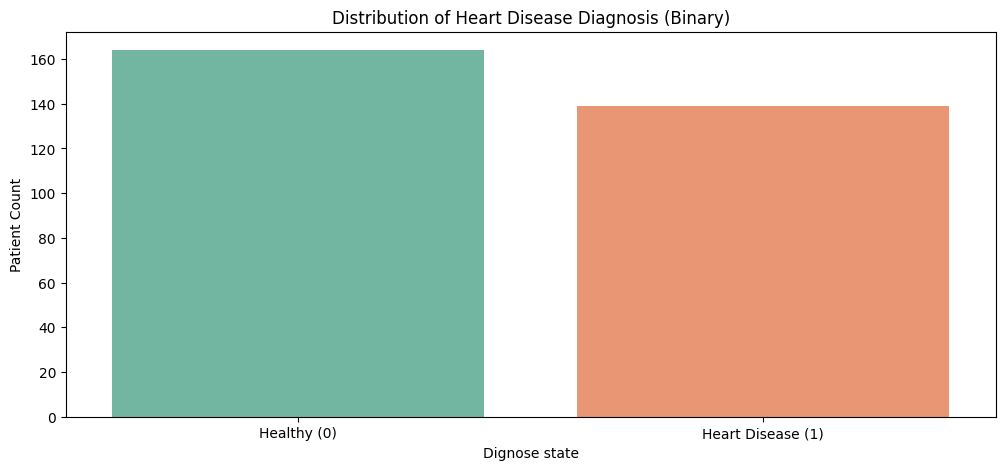

In [15]:
# convert text to numerical values to allow evalution of the distribution of the target variable
target_numeric = df['num'].astype(int)

# create binary table 0 if healthy 1 if in any stage of heart disease
target_binary = target_numeric.apply(lambda x: 0 if x == 0 else 1)

plt.figure(figsize=(12, 5))
sns.countplot(x=target_binary, palette='Set2')
plt.title('Distribution of Heart Disease Diagnosis (Binary)')
plt.xlabel('Dignose state')
plt.ylabel('Patient Count')
plt.xticks(ticks=[0,1], labels=['Healthy (0)', 'Heart Disease (1)'])
plt.show()

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.097542  0.104139  0.284946  0.208950  0.118530   
sex      -0.097542  1.000000  0.010084 -0.064456 -0.199915  0.047862   
cp        0.104139  0.010084  1.000000 -0.036077  0.072319 -0.039975   
trestbps  0.284946 -0.064456 -0.036077  1.000000  0.130120  0.175340   
chol      0.208950 -0.199915  0.072319  0.130120  1.000000  0.009841   
fbs       0.118530  0.047862 -0.039975  0.175340  0.009841  1.000000   
restecg   0.148868  0.021647  0.067505  0.146560  0.171043  0.069564   
thalach  -0.393806 -0.048663 -0.334422 -0.045351 -0.003432 -0.007854   
exang     0.091661  0.146201  0.384060  0.064762  0.061310  0.025665   
oldpeak   0.203805  0.102173  0.202277  0.189171  0.046564  0.005747   
slope     0.161770  0.037533  0.152050  0.117382 -0.004062  0.059894   
ca        0.362605  0.093185  0.233214  0.098773  0.119000  0.145478   
thal      0.127389  0.380936  0.265246  0.133554  0.014214  0.07

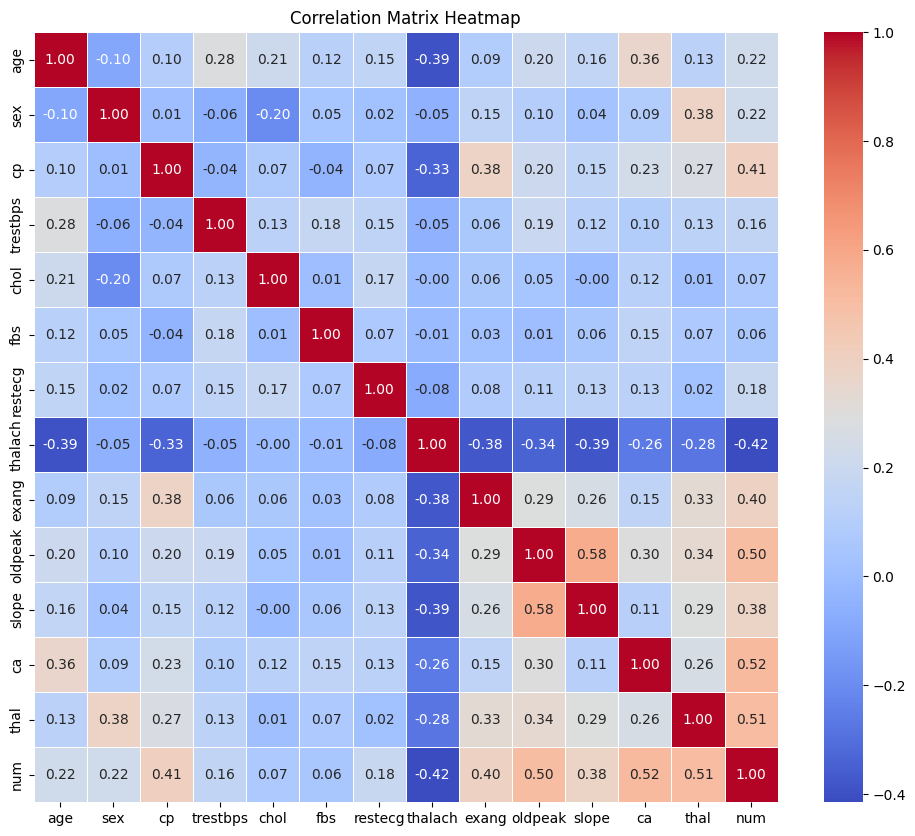

In [18]:
# convert all columns to numeric types, forcing string ? to NaN
numeric_df = df.apply(pd.to_numeric, errors='coerce')
# calculate the correlation matrix
corr_matrix = numeric_df.corr()
print(corr_matrix) 
# plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

### Official Phase 3 Observations:
1. [cite_start]**Missing Data**: Columns like `ca` and `thal` contain hidden missing values disguised as `?` characters. [cite_start]These require structural mathematical imputation during preprocessing[cite: 10].
2. [cite_start]**Target Balance**: The target class `num` is distributed across five categories. [cite_start]Converting this into a binary classification task (0 = Healthy, 1 = Sick) will balance our classes cleanly and match our medical goals[cite: 9, 11].
3. **Correlations**: Features like `thalach` (max heart rate) display noticeable negative correlations with patient age and target diagnosis severity, acting as an important prediction feature.
